# Does the market really move on Payrolls Friday? 📰📆
### The Nonfarm-Payrolls day effect — a legend that's *half* true, and the tradable half isn't the half you'd think

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Louder%2C_not_directional%3F: Confirmed](https://img.shields.io/badge/Louder%2C_not_directional%3F-Confirmed-8b949e?style=flat-square)

Once a month, on a Friday morning published **months in advance**, the Bureau of Labor Statistics drops the Employment Situation report at 8:30 am Eastern — the single most-watched number in macro. Trading desks staff up for it, volatility markets price it in, and financial media treat it like a market-moving event unto itself.

That's the claim we test: *does the S&P actually behave systematically on payrolls morning — and if so, can you get paid for knowing that?*

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 353 *actual* NFP release dates (1997→2026), hardcoded from BLS records — not a "first Friday" pattern guess. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from payrolls_day_effect import data, strategy as st

NFP_CAL = data.nfp_calendar()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY = data.load_real()
    SESSIONS, N_MAPPED = data.map_to_sessions(SPY.index, NFP_CAL)
    DF = st.day_frame(SPY, SESSIONS)
else:
    SPY = SESSIONS = DF = None
print("real cache present:", HAVE_REAL, "| scheduled NFP releases:", len(NFP_CAL),
      "| tape days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1997-01-02', 'end': '2026-06-30', 'n_nfp': 353, 'n_rest': 7065, 'cal_lo': '1997-01-10', 'cal_hi': '2026-06-05', 'n_mapped': 8, 'nfp_bps': 12.43, 'rest_bps': 3.37, 'gap_bps': 9.06, 'welch_t': 1.31, 'nw_t': 1.31, 'hit': 206, 'hit_pct': 58.4, 'wilson': (53.2, 63.4), 'rest_hit_pct': 54.1, 'placebo_p': 0.079, 'placebo_mean': 3.33, 'placebo_sd': 6.31, 'placebo_draws': 20000, 'event': {-3: (6.1, 0.3), -2: (17.05, 2.08), -1: (-2.05, -0.93), 0: (12.43, 1.19), 1: (-7.16, -1.6), 2: (0.67, -0.53), 3: (-4.9, -1.3)}, 'runup_bps': 21.1, 'runup_t': 2.07, 'spy_fomc': 1.474, 'spy_rest': 1.342, 'spy_t': 2.5, 'era_early': 13.58, 'era_early_n': 192, 'era_early_t': 1.16, 'era_late': 11.06, 'era_late_n': 161, 'era_late_t': 0.63, 'era_diff_t': -0.19, 'tm_gross': 12.43, 'tm_net5': 2.43, 'tm_net10': -7.57, 'tm_rest': 3.37, 'tm_t': 1.31, 'tm_n': 353, 'tm_hit': 58.4, 'tm_worst': -6.0, 'tm_ann5': 0.29, 'tm_ann10': -0.91, 'syn_null_mean': 0.16, 'syn_null_sd': 1.2, 'syn_null_fire': 2, 'syn_planted_t': 2.46, 'fp_spy': '7eebd76787d8'}


real cache present: True | scheduled NFP releases: 353 | tape days: 7418


## The answer first

| Question | Answer |
|---|---|
| Does SPY move *more* on payrolls morning? | **Yes.** The high-low swing is **1.47%** vs **1.34%** on a normal day — a real, measurable bump in how loud the session is. |
| Does it move in a *knowable direction*? | **Not really.** The average release-day return is **+12.4 bps** vs +3.4 bps normally — bigger, but not statistically distinguishable from luck (a random 353-day calendar produces something this big about **8% of the time**). |
| Is there a build-up before the report? | **Maybe, faintly** — but it's one flagged hit among seven things we checked, not a certified pattern. |
| Can you trade it? | **No.** A naive "own SPY only on payrolls day" plan nets essentially nothing after 5 bps of costs (**+0.29%/yr**) and loses money at 10 bps — and a single bad release morning can cost **-6.0%**. |

> The morning is louder. The trade isn't there.

## 1 · The claim

> *"Payrolls Friday is the biggest data point of the month — the market either breathes a sigh of relief once it's out, or builds up nervous energy beforehand. Either way, you can feel it in the tape."*

Academics agree scheduled macro releases produce real, measurable spikes in realized volatility (Andersen & Bollerslev 1998; Balduzzi, Elton & Green 2001). The question isn't whether the report *matters* — it's whether that mattering shows up as a **direction you could have bet on**, not just noise.

## 2 · So what?

If payrolls morning has a systematic tilt, it's one of the cleanest possible trades: a single, scheduled, public-calendar bet, twelve times a year, no guesswork about *when*. If it's just noise wearing a headline, the honest lesson is that "the market moves on big news days" doesn't automatically mean "you can predict which way" — loud and knowable are two different things.

## 3 · How would we even know?

- **The calendar.** All **353** actual NFP release dates from 1997-01-10 to 2026-06-05, hardcoded from BLS records (not a weekday-pattern guess). The report lands at 8:30 am ET, before the 9:30 am open, so the daily close-to-close bar fully contains the reaction.
- **The comparison.** SPY's release-day return vs the other **7,065** trading days since 1997.
- **The luck check.** Draw 353 random days instead, 20,000 times, two-sided — how often does a random calendar produce a gap this large in *either* direction?
- **The trade check.** Buy SPY at the close *before* release day (the date is public months ahead), sell at the release-day close, pay costs.

## 4 · The teardown — let's actually look

**First, the headline.** Average daily SPY return on release days vs every other day.

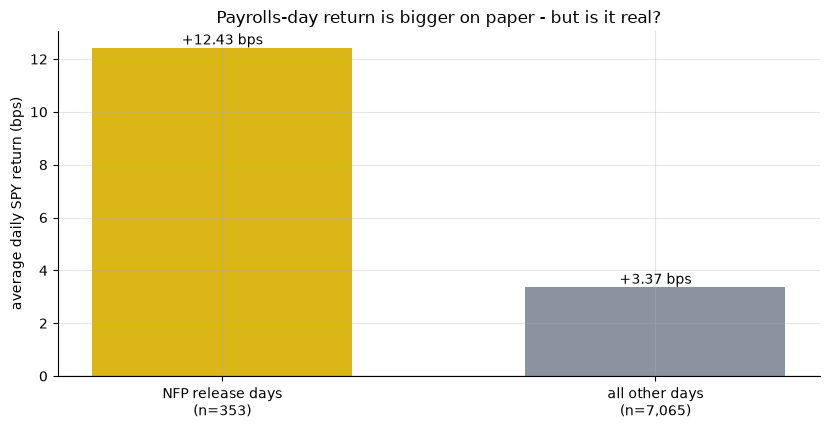

release days +12.43 bps   other days +3.37 bps


In [2]:
if HAVE_REAL:
    s = st.nfp_day_stats(DF)
    fp, rp = s['nfp_bps'], s['rest_bps']
else:
    fp, rp = R['nfp_bps'], R['rest_bps']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['NFP release days\n(n=353)','all other days\n(n=7,065)'], [fp, rp],
       color=[AMBER, GREY], width=.6)
for i,v in enumerate([fp, rp]): ax.annotate(f'{v:+.2f} bps',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average daily SPY return (bps)')
ax.set_title('Payrolls-day return is bigger on paper - but is it real?')
plt.tight_layout(); plt.show()
print(f'release days {fp:+.2f} bps   other days {rp:+.2f} bps')

**+12.43 bps** on the average release day vs **+3.37 bps** normally — about **3.7×** the baseline. SPY rose on **206/353 = 58.4%** of release days, but ordinary days already rise **54.1%** of the time (SPY drifts up over the long run) — so that hit rate is barely above the baseline. The quants notebook shows a random calendar beats this gap about **8 times in 100** — not the 1-in-20,000 the FOMC study found for the VIX crush.

**Next, the anatomy.** What does the week around release day look like?

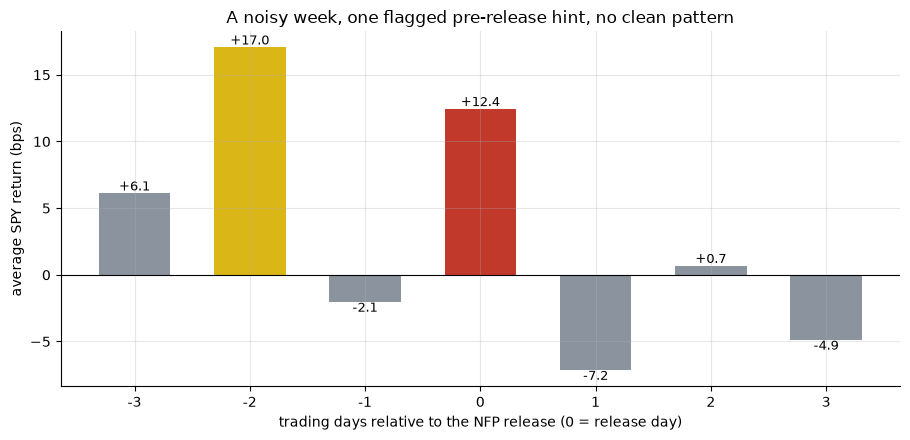

offsets: {-3: 6.1, -2: 17.05, -1: -2.05, 0: 12.43, 1: -7.16, 2: 0.67, 3: -4.9}


In [3]:
if HAVE_REAL:
    ev = st.event_study(DF, SESSIONS)
    ks, ms = list(ev.index), list(ev['mean_bps'])
else:
    ks = sorted(R['event']); ms = [R['event'][k][0] for k in ks]
fig, ax = plt.subplots(figsize=(9.2, 4.5))
cols = [RED if k==0 else (AMBER if k==-2 else GREY) for k in ks]
ax.bar([str(k) for k in ks], ms, color=cols, width=.62)
for i,v in enumerate(ms): ax.annotate(f'{v:+.1f}',(i,v),ha='center',
    va='top' if v<0 else 'bottom', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('trading days relative to the NFP release (0 = release day)')
ax.set_ylabel('average SPY return (bps)')
ax.set_title('A noisy week, one flagged pre-release hint, no clean pattern')
plt.tight_layout(); plt.show()
print('offsets:', {k: round(m,2) for k,m in zip(ks, ms)})

The bars bounce around without a clean story. Day −2 (**+17.05 bps**) and the cumulative 3-day run-up nominally clear the desk's statistical bar — but that's **one flagged result among seven offsets we checked**, exactly the kind of after-the-fact pattern honest research is supposed to be suspicious of. Day +1 is *negative* (−7.16 bps) — if the report were cleanly bullish, you'd expect follow-through, not a give-back.

**And here's the interesting part** — the market IS louder that morning, even though it isn't more *predictable*:

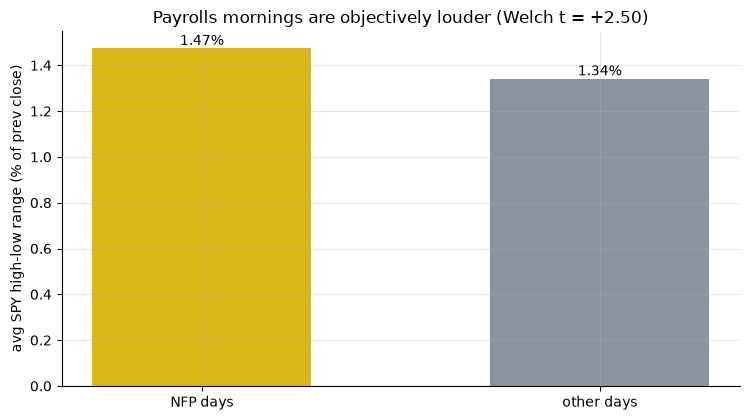

SPY range: NFP days 1.474%  vs other 1.342%


In [4]:
if HAVE_REAL:
    rg = st.spy_range_stats(DF)
    a, b = rg['nfp_range_pct'], rg['rest_range_pct']
else:
    a, b = R['spy_fomc'], R['spy_rest']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['NFP days','other days'], [a, b], color=[AMBER, GREY], width=.55)
for i,v in enumerate([a, b]): ax.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('avg SPY high-low range (% of prev close)')
ax.set_title('Payrolls mornings are objectively louder (Welch t = +2.50)')
plt.tight_layout(); plt.show()
print(f'SPY range: NFP days {a:.3f}%  vs other {b:.3f}%')

SPY swings **1.47%** high-to-low on release days vs **1.34%** normally — this one *does* clear the statistical bar (Welch *t* = +2.50). Payrolls mornings really are noisier. It's the same "scheduled uncertainty resolving" signature the desk found for the VIX on Fed decision days ([637-fomc-vol-crush](../../637-fomc-vol-crush/)) — except there, the *direction* was also certified. Here, only the *loudness* is.

**Finally, the trade.** Even taking the raw numbers at face value, does the naive "own it only on release day" plan actually pay?

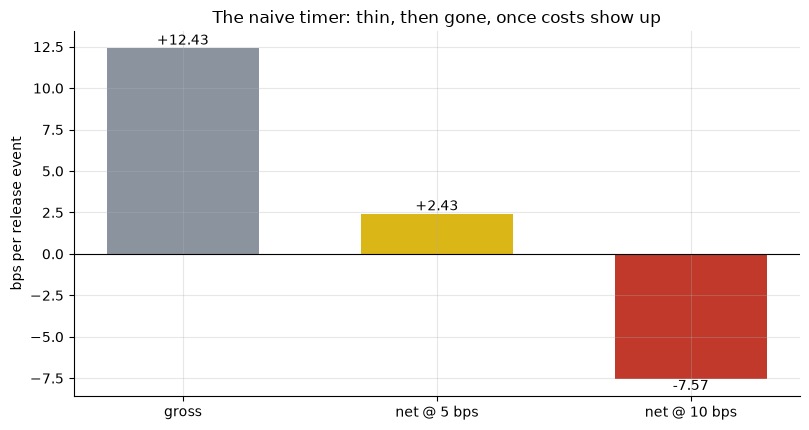

timer: gross +12.43 -> net +2.43 (5bps) / -7.57 (10bps) bps


In [5]:
if HAVE_REAL:
    tc5 = st.timer_capture(DF, cost_bps=5.0)
    tc10 = st.timer_capture(DF, cost_bps=10.0)
    g, n5, n10 = tc5['gross_bps'], tc5['net_bps'], tc10['net_bps']
else:
    g, n5, n10 = R['tm_gross'], R['tm_net5'], R['tm_net10']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['gross','net @ 5 bps','net @ 10 bps'], [g, n5, n10],
       color=[GREY, AMBER, RED], width=.6)
for i,v in enumerate([g, n5, n10]): ax.annotate(f'{v:+.2f}',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('bps per release event')
ax.set_title('The naive timer: thin, then gone, once costs show up')
plt.tight_layout(); plt.show()
print(f'timer: gross {g:+.2f} -> net {n5:+.2f} (5bps) / {n10:+.2f} (10bps) bps')

Gross **+12.43 bps/event** becomes **+2.43 bps** after 5 bps costs (~+0.29%/yr from twelve trades a year — not worth the screen time) and **-7.57 bps** — negative — at 10 bps. The worst single release day cost **-6.0%**. And remember: the gross number was never statistically certified to begin with (*t* = 1.31). There's no edge here to protect.

## 5 · The verdict

- **Signal — Weak.** SPY does move more on release day on average (+12.4 vs +3.4 bps), but the gap doesn't clear the statistical bar (Welch *t* = +1.31, placebo *p* = 0.079) and the hit rate barely beats the baseline.
- **Tradability — Mirage.** The naive timer nets almost nothing after realistic costs and goes negative at a slightly higher cost, on top of an uncertified point estimate and a −6% worst day.
- **"Louder, not directional?" — Confirmed.** The realized range genuinely clears the bar — payrolls mornings ARE noisier, mechanically. That loudness just never becomes a bankable direction.

## 6 · Going further 🚪

- **The pre-release hint deserves its own honest test.** A dedicated,
  pre-registered study of the [−3..−1] window (with a multiple-comparison
  correction built in from the start) is the natural sequel — this study flags
  it, it doesn't certify it.
- **Where the real edge (if any) probably lives** is in the *options market*
  around the print — the implied-vol crush after the number, mirroring what
  [637-fomc-vol-crush](../../637-fomc-vol-crush/) found for FOMC afternoons —
  not in a directional long-SPY timer.
- **Sibling studies:** [385-jobless-claims-momentum](../../385-jobless-claims-momentum/)
  (weekly claims as a slow *leading* indicator) and
  [602-macro-announcement-premium](../../602-macro-announcement-premium/) (the
  pooled CPI+FOMC+NFP bundle, shown there to be an FOMC-only effect) ask
  related but distinct questions — neither isolates the NFP morning itself.

*Think the pre-release drift is real? Show a corrected, pre-registered *t* ≥ 2 on an out-of-sample window — then we'll talk.*